# Random Forest Classifier

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import pickle
from utils2 import get_classifier_metrics

## Lectura del conjunto de datos procesado

In [24]:
file_path = '/workspaces/CarlosRestrepo-machine-learning-python/data/processed/diabetes.pkl'

# Abrir el archivo en modo binario de lectura ('rb')
with open(file_path, 'rb') as file:
    # Cargar el objeto (tu DataFrame) usando el manejador de archivo 'file'
    df = pickle.load(file)

## Selección de variables

In [25]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,0,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,0,26.6,0.351,31,0
2,8.0,183.0,64.0,29.0,0,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94,28.1,0.167,21,0
4,4.0,137.0,40.0,35.0,168,43.1,2.288,33,1


## Split

In [26]:
X = df.drop('Outcome', axis=1)
y =df['Outcome']


X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

X_train.head()

## Modelado y Ajuste

In [27]:
model = RandomForestClassifier(random_state=18)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Visualización

Text(0.5, 1.0, 'Random Forest')

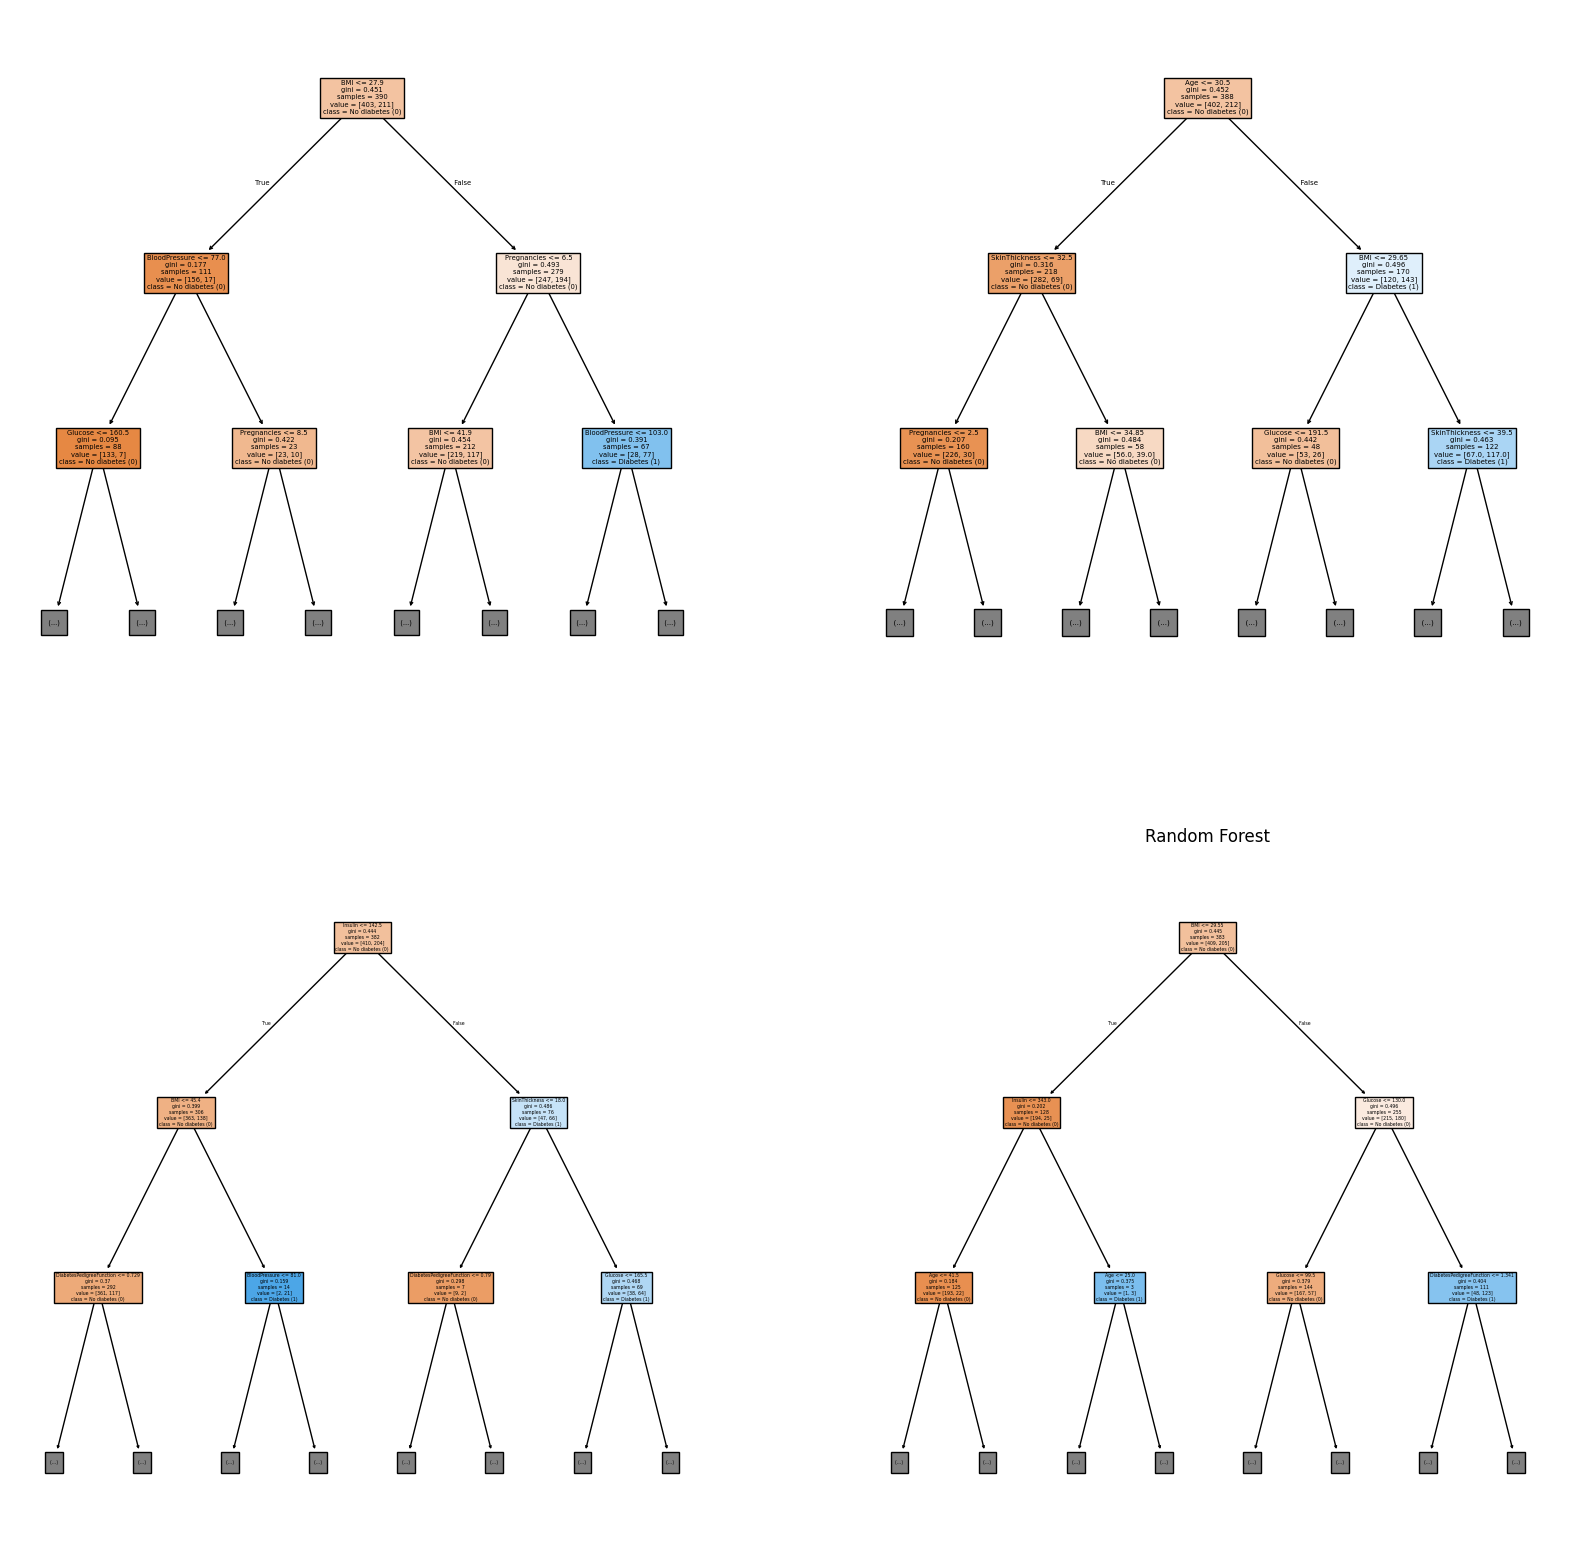

In [49]:
fig, axis = plt.subplots(2, 2, figsize=(20, 20))

# Se  muestran los 4 primeros árboles de los 100 generados por defecto.
class_names = ['No diabetes (0)', 'Diabetes (1)']
tree.plot_tree(model.estimators_[0], ax=axis[0, 0],
               max_depth=2,
               feature_names=list(X_train.columns), class_names=class_names, filled=True)
tree.plot_tree(model.estimators_[1], ax=axis[0, 1],
               max_depth=2,
               feature_names=list(X_train.columns), class_names=class_names, filled=True)
tree.plot_tree(model.estimators_[2], ax=axis[1, 0],
               max_depth=2,
               feature_names=list(X_train.columns), class_names=class_names, filled=True)
tree.plot_tree(model.estimators_[3], ax=axis[1, 1],
               max_depth=2,
               feature_names=list(X_train.columns), class_names=class_names, filled=True)

plt.title("Random Forest")

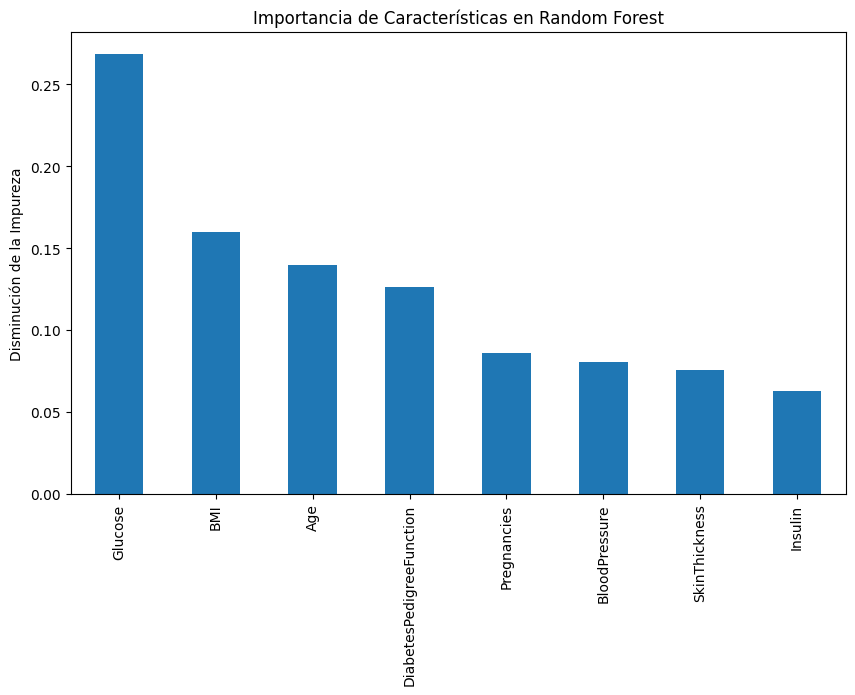

In [29]:
#Obtener la importancia de las características
importances = model.feature_importances_
feature_names = X_train.columns
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

#Graficar la importancia
fig, ax = plt.subplots(figsize=(10, 6))
forest_importances.plot.bar(ax=ax)
ax.set_title("Importancia de Características en Random Forest")
ax.set_ylabel("Disminución de la Impureza")
plt.show()

#### Observaciones:
> - El eje Y de la gráfica de importancia de características tiene el nombre "Disminución de la Impureza" porque este es el método interno que utiliza el algoritmo Random Forest para calcular la importancia de cada variable predictora.
> - `Glucosa` es con diferencia la característica mas importante dentro de el DataSet.
> - `Pregnancies`, `BloodPressure`, `SkinThickness` ,  y `Insulin` son las características que se encuentran en la parte baja de la jerarquía de importancia y tienen un valor bajo similar entre ellas.

## Paso 6. Predicción

In [30]:
y_pred_test = model.predict(X_test)
y_pred_test

array([1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0])

In [31]:
len(y_pred_test)

154

In [32]:
y_pred_train = model.predict(X_train)
y_pred_train

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,

In [33]:
len(y_pred_train)

614

In [34]:
#Evaluación Acurracy
model_accuracy = accuracy_score(y_test, y_pred_test)
model_accuracy

0.7662337662337663

In [35]:
#Metricas de Random Forest
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train)

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.766234,0.766234,0.766234,0.766234


#### Observaciones: 
> - El conjunto de entrenamiento indica que el modelo **se ha memorizado** los datos de entrenamiento.
> - El modelo consigue una puntuación de precisión de `0.76`
> - El modelo de Random Forest está mostrando signos severos de sobreajuste.

## Hiperparametrización

In [ ]:
#Definir hiperparámetros a probar
param_grid = {'n_estimators': [49, 50, 51, 52],
                   'max_depth': [10, 12, 13],
                   'min_samples_split': [2, 3, 4, 5],
                   'min_samples_leaf': [7, 8, 9, 10],
                   "max_features": ["sqrt", "log2"]}

#Implementar GridSearchCV
grid_search = GridSearchCV(model, param_grid, cv=5,)

#Entrenamos
grid_search.fit(X_train, y_train)

#Mostrar los mejores hiperparámetros encontrados
grid_search.best_params_

{'max_depth': 12,
 'max_features': 'sqrt',
 'min_samples_leaf': 9,
 'min_samples_split': 2,
 'n_estimators': 51}

In [37]:
# Mejor modelo
grid_search.best_estimator_

,n_estimators,51
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,9
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
# Entrenamos
grid_search.best_estimator_.fit(X_train, y_train)

,n_estimators,51
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,9
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
# Predicción sobre X_test
y_pred_test_grid = grid_search.best_estimator_.predict(X_test)
y_pred_test_grid

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1])

In [40]:
# Predicción sobre X_train
y_pred_train_grid = grid_search.best_estimator_.predict(X_train)
y_pred_train_grid

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,

In [41]:
# Comparamos métricas
get_classifier_metrics(y_pred_test_grid, y_test, y_pred_train_grid, y_train)

,Accuracy,F1 Score,Precision,Recall
Train set,0.856678,0.856678,0.856678,0.856678
Test set,0.733766,0.733766,0.733766,0.733766


#### Observaciones:
> - La hiperparametrización ha arrojado una puntuacion de precision en el modelo del `0.73` , `-0.3` de puntuacion percentual respecto al modelo inicial.
> - El aspecto positivo de este modelo con los hiperparametros es que ahora el modelo no memoriza los datos para el entrenamiento.

Text(0.5, 1.0, 'Matriz de Confusión')

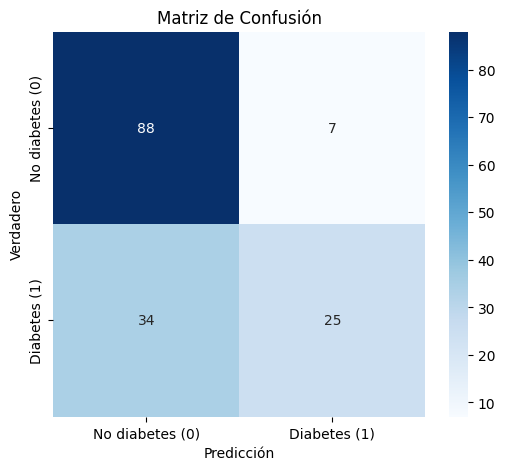

In [45]:
# Obtener el mejor modelo
best_model = grid_search.best_estimator_

# Hacer predicciones con el mejor modelo
y_pred_best = best_model.predict(X_test)

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred_best)

# Visualización
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix,
            annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.title("Matriz de Confusión")

#### Observaciones:
> La matriz de confusión muestra:
> - 90 verdaderos negativos y 5 falsos positvos.
> 
> - 29 verdaderos positivos y 30 falsos negativos.

## Accuracy vs n_estimators

Text(0, 0.5, 'Accuracy')

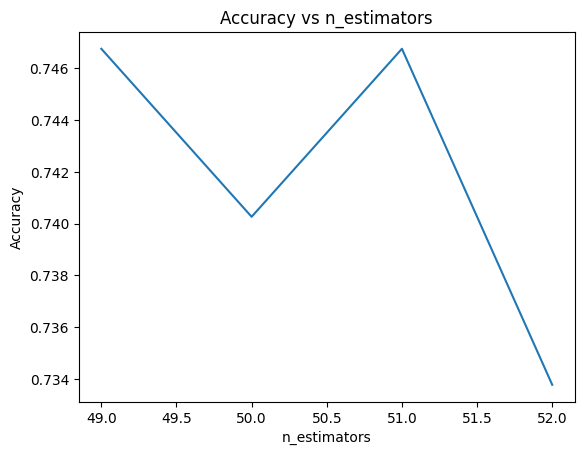

In [48]:
n_estimators_list = [49, 50, 51, 52]
accuracies_n = []

for n in n_estimators_list:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies_n.append(accuracy_score(y_test, y_pred))

plt.plot(n_estimators_list, accuracies_n)
plt.title("Accuracy vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")

#### Observaciones:
> - Actualmente la gráfica presenta 4 valores consecutivos, pero inicie la hiper parametrización con distintos rangos.
> - El valor óptimo es n_estimators=51, ya que proporciona la mayor precisión (cercana a 0.7468).
> - n_estimators=49 también presenta una precisión muy competitiva.

Text(0, 0.5, 'Accuracy')

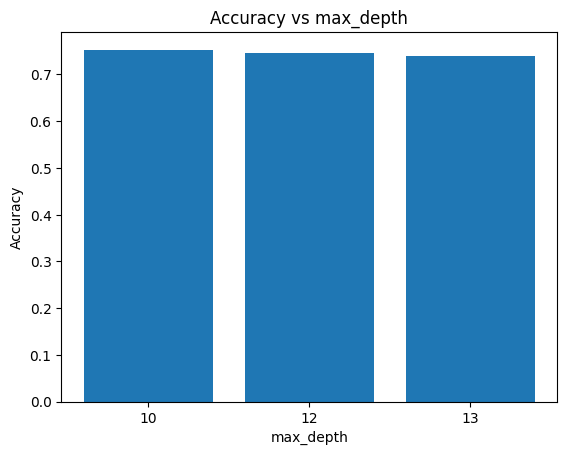

In [47]:
# Accuracy vs max_depth
max_depth_list = [10, 12, 13]
accuracies_depth = []

for depth in max_depth_list:
    model = RandomForestClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies_depth.append(accuracy_score(y_test, y_pred))

plt.bar(['10', '12', '13'], accuracies_depth)
plt.title("Accuracy vs max_depth")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")

#### Observaciones:
> - El rendimiento del modelo se mantiene casi idéntico en los tres valores de profundidad probados.
> - La precisión es ligeramente más alta para max_depth=10.
> - **Eficiencia:** Un árbol con max_depth=10 es menos complejo y se entrena más rápido que uno con max_depth=13. Dado que la precisión es comparable o incluso ligeramente mejor, se debe elegir el valor más bajo max_depth=10 para optimizar la eficiencia computacional sin sacrificar el rendimiento predictivo.

## Paso 7. Guardado del modelo

In [ ]:
with open('../models/diabetes-random-forest-classifier.pkl', 'wb') as file:
    pickle.dump(model, file)